# Testing on up to 5 lines — endpoint method with 1-degree snapping

This notebook trains a CNN to convert a 64×64 black-and-white raster image containing up to 5 synthetic lines into vector line endpoints.

The synthetic data still favours common technical-drawing angles, but the model no longer predicts an angle class directly. Instead, it predicts endpoints and the final vector output is snapped to the nearest 1-degree angle during decoding/export.


# Key changes

* The model predicts endpoints again: `x1, y1, x2, y2, confidence`.
* The synthetic training images still use weighted angle generation.
* The model is **not** manually given the angle weights.
* The final prediction decoder calculates the angle from the predicted endpoints and snaps it to the nearest 1 degree.
* This avoids the weaker 180-class angle prediction stage.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from PIL import Image, ImageDraw

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Settings

Increase in synthetic training data to see if it improves output

In [2]:
IMG_SIZE = 64

N_TRAIN = 10000
N_TEST = 2000

VECTOR_EPOCHS = 50
RASTER_EPOCHS = 100

BATCH_SIZE = 32

np.random.seed(42)
tf.random.set_seed(42)

## Create synthetic training data

Each sample contains between `MIN_LINES` and `MAX_LINES` black lines on a white background.

Each line label is:

```text
x1, y1, x2, y2, confidence
```

The synthetic generator favours common technical-drawing angles, but the model only sees the image and endpoint labels.


This part was modified to give more probable lines, it's more likely that engineering drawings have lines on set angles. These weightings can be adjusted later.
This may also be useful if scanning images with impectly straight lines.

Modified the confidence threshold to see if it was better at predicting less than 5 lines.

In [3]:
MAX_LINES = 5
MIN_LINES = 1
CONFIDENCE_THRESHOLD = 0.9

# Each predicted line is:
# x1, y1, x2, y2, confidence
VALUES_PER_LINE = 5

# These weights control the synthetic data distribution only.
# The model is not manually given these weights.
ANGLE_WEIGHT_90 = 40      # 0, 90
ANGLE_WEIGHT_45 = 25      # 45, 135
ANGLE_WEIGHT_60 = 15      # 60, 120
ANGLE_WEIGHT_30 = 10      # 30, 150
ANGLE_WEIGHT_5 = 7        # other multiples of 5 degrees
ANGLE_WEIGHT_OTHER = 3    # all other integer-degree angles

LINE_WIDTH = 1


def build_angle_groups():
    """
    Build disjoint angle groups from 0 to 179 degrees.

    180 degrees is excluded because a line at 180 degrees is the same direction as 0 degrees.
    """
    all_angles = set(range(0, 180))

    angle_90 = {angle for angle in all_angles if angle % 90 == 0}

    angle_45 = {
        angle for angle in all_angles
        if angle % 45 == 0 and angle not in angle_90
    }

    angle_60 = {
        angle for angle in all_angles
        if angle % 60 == 0
        and angle not in angle_90
        and angle not in angle_45
    }

    angle_30 = {
        angle for angle in all_angles
        if angle % 30 == 0
        and angle not in angle_90
        and angle not in angle_45
        and angle not in angle_60
    }

    angle_5 = {
        angle for angle in all_angles
        if angle % 5 == 0
        and angle not in angle_90
        and angle not in angle_45
        and angle not in angle_60
        and angle not in angle_30
    }

    used_angles = angle_90 | angle_45 | angle_60 | angle_30 | angle_5
    angle_other = all_angles - used_angles

    return {
        "90": sorted(angle_90),
        "45": sorted(angle_45),
        "60": sorted(angle_60),
        "30": sorted(angle_30),
        "5": sorted(angle_5),
        "other": sorted(angle_other),
    }


ANGLE_GROUPS = build_angle_groups()


def choose_weighted_angle():
    """
    Choose one integer-degree angle between 0 and 179.

    The weighting is only used to create the synthetic images.
    The model learns angle tendencies from the examples, not from these weights directly.
    """
    group_names = ["90", "45", "60", "30", "5", "other"]

    group_weights = np.array([
        ANGLE_WEIGHT_90,
        ANGLE_WEIGHT_45,
        ANGLE_WEIGHT_60,
        ANGLE_WEIGHT_30,
        ANGLE_WEIGHT_5,
        ANGLE_WEIGHT_OTHER
    ], dtype="float32")

    if np.sum(group_weights) <= 0:
        raise ValueError("At least one angle weight must be greater than 0.")

    group_probabilities = group_weights / np.sum(group_weights)

    selected_group = np.random.choice(group_names, p=group_probabilities)
    selected_angle = np.random.choice(ANGLE_GROUPS[selected_group])

    return int(selected_angle)


def create_line_image(img_size=64, min_length=12, min_lines=1, max_lines=5):
    """
    Create one image containing between min_lines and max_lines random black lines.

    The image generator restricts line angles to integer-degree angles.
    The label stores endpoints only:

        [x1, y1, x2, y2, confidence]

    The final prediction decoder later snaps predicted endpoint angles to the nearest 1 degree.
    """

    def random_line():
        while True:
            angle_degrees = choose_weighted_angle()
            angle_radians = np.deg2rad(angle_degrees)

            cos_a = np.cos(angle_radians)
            sin_a = np.sin(angle_radians)

            # Maximum possible full line length that can fit in the image at this angle
            max_length_x = np.inf if abs(cos_a) < 1e-8 else (img_size - 1) / abs(cos_a)
            max_length_y = np.inf if abs(sin_a) < 1e-8 else (img_size - 1) / abs(sin_a)
            max_possible_length = min(max_length_x, max_length_y)

            if max_possible_length < min_length:
                continue

            line_length = np.random.uniform(min_length, max_possible_length)

            dx = cos_a * line_length / 2
            dy = sin_a * line_length / 2

            # Choose a centre point that keeps both endpoints inside the image
            cx_min = abs(dx)
            cx_max = (img_size - 1) - abs(dx)
            cy_min = abs(dy)
            cy_max = (img_size - 1) - abs(dy)

            if cx_min > cx_max or cy_min > cy_max:
                continue

            cx = np.random.uniform(cx_min, cx_max)
            cy = np.random.uniform(cy_min, cy_max)

            x1 = int(round(cx - dx))
            y1 = int(round(cy - dy))
            x2 = int(round(cx + dx))
            y2 = int(round(cy + dy))

            # Safety check after rounding
            if not (0 <= x1 < img_size and 0 <= y1 < img_size):
                continue
            if not (0 <= x2 < img_size and 0 <= y2 < img_size):
                continue

            actual_length = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

            if actual_length >= min_length:
                return x1, y1, x2, y2, angle_degrees

    number_of_lines = np.random.randint(min_lines, max_lines + 1)

    lines = [random_line() for _ in range(number_of_lines)]

    # Sort line slots by centre point so labels are more consistent for training
    lines = sorted(
        lines,
        key=lambda line: (
            (line[0] + line[2]) / 2,
            (line[1] + line[3]) / 2
        )
    )

    image = Image.new("L", (img_size, img_size), color=255)
    draw = ImageDraw.Draw(image)

    label_values = []

    for line in lines:
        x1, y1, x2, y2, angle_degrees = line

        draw.line((x1, y1, x2, y2), fill=0, width=LINE_WIDTH)

        label_values.extend([
            x1 / (img_size - 1),
            y1 / (img_size - 1),
            x2 / (img_size - 1),
            y2 / (img_size - 1),
            1.0
        ])

    # Fill unused line slots with zeros
    while len(label_values) < max_lines * VALUES_PER_LINE:
        label_values.extend([0.0, 0.0, 0.0, 0.0, 0.0])

    image_array = np.array(image).astype("float32") / 255.0
    image_array = np.expand_dims(image_array, axis=-1)

    label = np.array(label_values, dtype="float32")

    return image_array, label


def create_dataset(n_samples, img_size=64):
    images = []
    labels = []

    for _ in range(n_samples):
        image, label = create_line_image(
            img_size=img_size,
            min_lines=MIN_LINES,
            max_lines=MAX_LINES
        )

        images.append(image)
        labels.append(label)

    return np.array(images), np.array(labels)


In [4]:
X_train, y_train = create_dataset(N_TRAIN, IMG_SIZE)
X_test, y_test = create_dataset(N_TEST, IMG_SIZE)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (10000, 64, 64, 1)
y_train: (10000, 25)
X_test: (2000, 64, 64, 1)
y_test: (2000, 25)


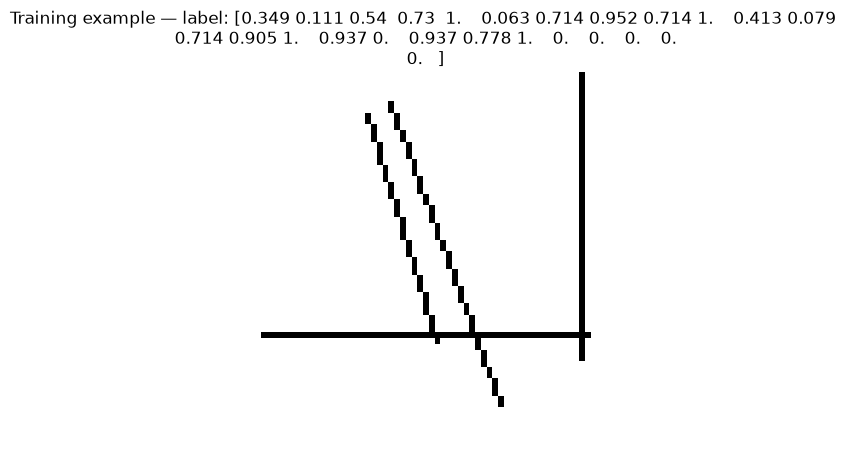

In [5]:
index = 0

plt.imshow(X_train[index].squeeze(), cmap="gray", vmin=0, vmax=1)
plt.title(f"Training example — label: {np.round(y_train[index], 3)}")
plt.axis("off")
plt.show()

## Build the CNN vector model

The CNN predicts endpoint vectors:

```text
[x1, y1, x2, y2, confidence] × MAX_LINES
```

The final output uses a sigmoid activation because all values are normalised between 0 and 1.


In [6]:
def build_vector_model():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1), name="raster_input")

    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.Flatten()(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    # Output is [x1, y1, x2, y2, confidence] × MAX_LINES
    # Sigmoid keeps all values between 0 and 1.
    vector_output = layers.Dense(
        MAX_LINES * VALUES_PER_LINE,
        activation="sigmoid",
        name="vector_output"
    )(x)

    return models.Model(inputs=inputs, outputs=vector_output, name="vector_model")


vector_model = build_vector_model()
vector_model.summary()


Model: "vector_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ raster_input (InputLayer)            │ (None, 64, 64, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 64, 64, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 8, 8, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       2,097,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vector_output (Dense)                │ (None, 25)                  │           3,225 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,373,785 (9.06 MB)

 Trainable params: 2,373,785 (9.06 MB)

 Non-trainable params: 0 (0.00 B)

## Coordinate loss

A line is the same line if its endpoints are swapped, so this loss checks both endpoint orders and uses the better one.

The coordinate loss is only applied to real line slots where `confidence = 1`. The confidence loss is applied to every slot.


In [7]:
def line_coordinate_loss(y_true, y_pred):
    """
    Loss for up to MAX_LINES endpoint-based lines.

    Each line is:
        x1, y1, x2, y2, confidence

    Reversed endpoints are treated as the same line:
        x1,y1 -> x2,y2
        is equivalent to
        x2,y2 -> x1,y1
    """

    y_true = tf.reshape(y_true, (-1, MAX_LINES, VALUES_PER_LINE))
    y_pred = tf.reshape(y_pred, (-1, MAX_LINES, VALUES_PER_LINE))

    true_coords = y_true[:, :, 0:4]
    pred_coords = y_pred[:, :, 0:4]

    true_conf = y_true[:, :, 4]
    pred_conf = y_pred[:, :, 4]

    # Endpoint order as predicted
    direct_loss = tf.reduce_mean(
        tf.square(true_coords - pred_coords),
        axis=-1
    )

    # Endpoint order reversed
    reversed_pred_coords = tf.stack([
        pred_coords[:, :, 2],
        pred_coords[:, :, 3],
        pred_coords[:, :, 0],
        pred_coords[:, :, 1]
    ], axis=-1)

    reversed_loss = tf.reduce_mean(
        tf.square(true_coords - reversed_pred_coords),
        axis=-1
    )

    coordinate_loss = tf.minimum(direct_loss, reversed_loss)

    # Only apply coordinate loss to real line slots
    coordinate_loss = coordinate_loss * true_conf

    real_line_count = tf.reduce_sum(true_conf, axis=1) + 1e-8

    coordinate_loss = tf.reduce_sum(
        coordinate_loss,
        axis=1
    ) / real_line_count

    confidence_loss = tf.keras.backend.binary_crossentropy(
        true_conf,
        pred_conf
    )

    confidence_loss = tf.reduce_mean(confidence_loss, axis=1)

    total_loss = coordinate_loss + 1.0 * confidence_loss

    return tf.reduce_mean(total_loss)


## Stage 1 — train the CNN on vector coordinates first

This prevents the raster model from collapsing into a fuzzy dot.

In [8]:
vector_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=line_coordinate_loss,
    metrics=["mae"]
)

# early stop if over-fitting

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_vector = vector_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=VECTOR_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 0.3666 - mae: 0.3717 - val_loss: 0.2196 - val_mae: 0.3600
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.2241 - mae: 0.3597 - val_loss: 0.1748 - val_mae: 0.3491
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - loss: 0.1855 - mae: 0.3545 - val_loss: 0.1488 - val_mae: 0.3508
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 0.1630 - mae: 0.3531 - val_loss: 0.1350 - val_mae: 0.3494
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 0.1472 - mae: 0.3532 - val_loss: 0.1300 - val_mae: 0.3440
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 0.1382 - mae: 0.3517 - val_loss: 0.1340 - val_mae: 0.3456
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 0.1235 - mae: 0.3495 - val_loss: 0.1341 - val_mae: 0.3447
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 0.1126 - mae: 0.3503 - val_loss: 0.1404 - val_mae: 0.3481


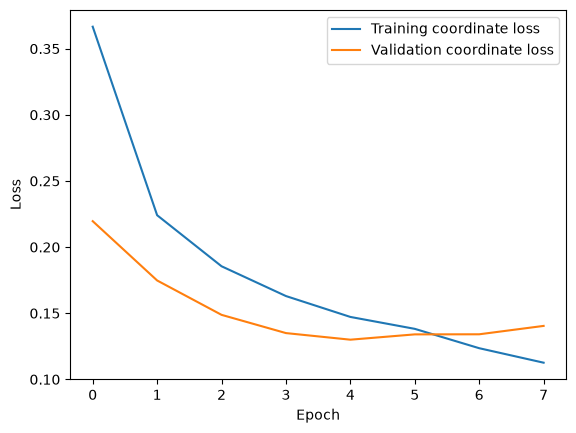

In [9]:
plt.plot(history_vector.history["loss"], label="Training coordinate loss")
plt.plot(history_vector.history["val_loss"], label="Validation coordinate loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Differentiable rasteriser

This layer converts predicted endpoint vectors back into a soft raster image using TensorFlow operations.

It is differentiable, so raster loss can backpropagate into the vector model.


In [10]:
class DifferentiableLineRasteriser(layers.Layer):
    def __init__(self, img_size=64, sigma=0.018, **kwargs):
        super().__init__(**kwargs)
        self.img_size = img_size
        self.sigma = sigma

        xs = tf.linspace(0.0, 1.0, img_size)
        ys = tf.linspace(0.0, 1.0, img_size)

        grid_x, grid_y = tf.meshgrid(xs, ys)

        self.grid_x = tf.reshape(grid_x, (1, 1, img_size, img_size))
        self.grid_y = tf.reshape(grid_y, (1, 1, img_size, img_size))

    def call(self, vectors):
        vectors = tf.reshape(vectors, (-1, MAX_LINES, VALUES_PER_LINE))

        x1 = tf.reshape(vectors[:, :, 0], (-1, MAX_LINES, 1, 1))
        y1 = tf.reshape(vectors[:, :, 1], (-1, MAX_LINES, 1, 1))
        x2 = tf.reshape(vectors[:, :, 2], (-1, MAX_LINES, 1, 1))
        y2 = tf.reshape(vectors[:, :, 3], (-1, MAX_LINES, 1, 1))

        confidence = tf.reshape(vectors[:, :, 4], (-1, MAX_LINES, 1, 1))

        px = self.grid_x
        py = self.grid_y

        dx = x2 - x1
        dy = y2 - y1

        length_squared = dx * dx + dy * dy + 1e-8

        t = ((px - x1) * dx + (py - y1) * dy) / length_squared
        t = tf.clip_by_value(t, 0.0, 1.0)

        closest_x = x1 + t * dx
        closest_y = y1 + t * dy

        distance_squared = tf.square(px - closest_x) + tf.square(py - closest_y)

        line_darkness = tf.exp(
            -distance_squared / (2.0 * self.sigma * self.sigma)
        )

        line_darkness = line_darkness * confidence

        # Combine multiple black lines on a white background
        combined_darkness = 1.0 - tf.reduce_prod(
            1.0 - line_darkness,
            axis=1
        )

        raster = 1.0 - combined_darkness
        raster = tf.expand_dims(raster, axis=-1)

        return raster


## Weighted raster loss

Normal MSE performs badly because most pixels are white. This weighted loss gives black line pixels much more importance.

In [11]:
def weighted_raster_loss(y_true, y_pred):
    black_pixel_weight = 40.0
    weights = 1.0 + black_pixel_weight * (1.0 - y_true)
    loss = weights * tf.square(y_true - y_pred)
    return tf.reduce_mean(loss)

## Stage 2 — train through the differentiable rasteriser

This model has two losses:

1. Raster loss: predicted raster should match the input raster.
2. Coordinate loss: predicted vector should not drift away from the true vector.

The raster loss is the important Option B part.

In [12]:
raster_output = DifferentiableLineRasteriser(
    img_size=IMG_SIZE,
    sigma=0.010,
    name="raster_output"
)(vector_model.output)

training_model = models.Model(
    inputs=vector_model.input,
    outputs=[raster_output, vector_model.output],
    name="option_b_training_model"
)

training_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=[weighted_raster_loss, line_coordinate_loss],
    loss_weights=[0.3, 1.0],
    metrics=[["mae"], ["mae"]]
)

early_stop_raster = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_raster = training_model.fit(
    X_train,
    [X_train, y_train],
    validation_data=(X_test, [X_test, y_test]),
    epochs=RASTER_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop_raster],
    verbose=1
)


Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - loss: 1.0940 - raster_output_loss: 0.9648 - raster_output_mae: 0.0702 - vector_output_loss: 0.1295 - vector_output_mae: 0.3592 - val_loss: 1.0730 - val_raster_output_loss: 0.9466 - val_raster_output_mae: 0.0741 - val_vector_output_loss: 0.1266 - val_vector_output_mae: 0.3595
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - loss: 1.0734 - raster_output_loss: 0.9451 - raster_output_mae: 0.0751 - vector_output_loss: 0.1286 - vector_output_mae: 0.3644 - val_loss: 1.0596 - val_raster_output_loss: 0.9338 - val_raster_output_mae: 0.0762 - val_vector_output_loss: 0.1263 - val_vector_output_mae: 0.3620
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - loss: 1.0624 - raster_output_loss: 0.9341 - raster_output_mae: 0.0773 - vector_output_loss: 0.1287 - vector_output_mae: 0.3688 - val_loss: 1.0557 - val_raster_output_loss: 0.9282 - val_raster_output_mae: 0.0779 - val_vector_output_loss: 0.1278 - val_vector_output_mae: 0.3678


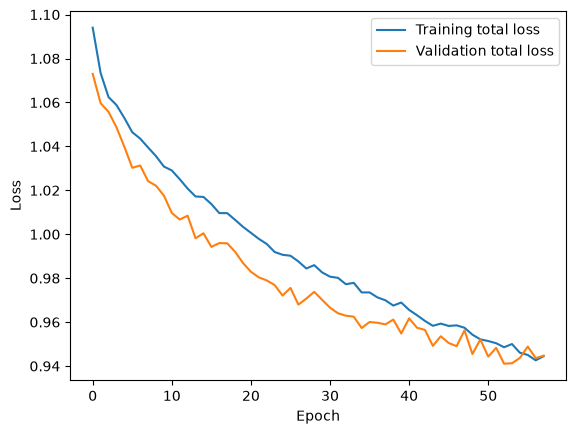

In [13]:
plt.plot(history_raster.history["loss"], label="Training total loss")
plt.plot(history_raster.history["val_loss"], label="Validation total loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Test the trained model

The decoder calculates an angle from the predicted endpoints, snaps it to the nearest 1 degree, and rebuilds the line from that snapped angle.


Predicted snapped lines:
Line 1: (22, 4) to (14, 60), angle=98°, confidence=1.00
Line 2: (47, 10) to (8, 52), angle=132°, confidence=1.00


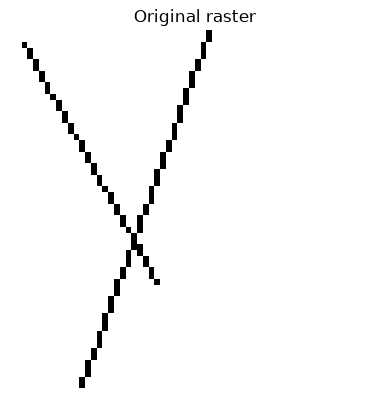

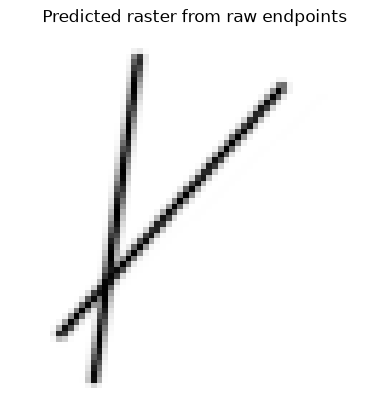

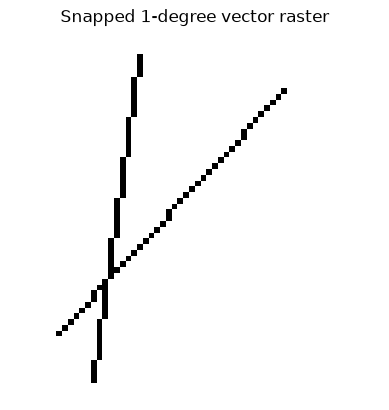

In [14]:
def snap_line_to_nearest_degree(x1, y1, x2, y2, img_size):
    """
    Take predicted endpoints and rebuild the line using the nearest 1-degree angle.

    The model itself predicts endpoints. The snap happens only during decoding/export.
    """

    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2

    dx = x2 - x1
    dy = y2 - y1

    length = np.sqrt(dx ** 2 + dy ** 2)

    if length < 1e-8:
        return int(round(x1)), int(round(y1)), int(round(x2)), int(round(y2)), 0

    angle_degrees = np.degrees(np.arctan2(dy, dx))

    # Lines are undirected, so keep angle between 0 and 179 degrees
    angle_degrees = angle_degrees % 180

    # Snap to nearest 1 degree
    snapped_angle = int(round(angle_degrees)) % 180

    angle_radians = np.deg2rad(snapped_angle)

    new_dx = np.cos(angle_radians) * length / 2
    new_dy = np.sin(angle_radians) * length / 2

    new_x1 = int(round(cx - new_dx))
    new_y1 = int(round(cy - new_dy))
    new_x2 = int(round(cx + new_dx))
    new_y2 = int(round(cy + new_dy))

    new_x1 = int(np.clip(new_x1, 0, img_size - 1))
    new_y1 = int(np.clip(new_y1, 0, img_size - 1))
    new_x2 = int(np.clip(new_x2, 0, img_size - 1))
    new_y2 = int(np.clip(new_y2, 0, img_size - 1))

    return new_x1, new_y1, new_x2, new_y2, snapped_angle


def decode_endpoint_vector(vector, img_size=64, confidence_threshold=0.5, snap=True):
    """
    Decode endpoint-based model output.

    Expected vector shape:
        MAX_LINES * VALUES_PER_LINE

    Each line:
        x1, y1, x2, y2, confidence
    """

    vector = vector.reshape(MAX_LINES, VALUES_PER_LINE)

    decoded_lines = []

    for line in vector:
        x1, y1, x2, y2, confidence = line

        if confidence >= confidence_threshold:
            x1 = x1 * (img_size - 1)
            y1 = y1 * (img_size - 1)
            x2 = x2 * (img_size - 1)
            y2 = y2 * (img_size - 1)

            if snap:
                x1, y1, x2, y2, angle = snap_line_to_nearest_degree(
                    x1, y1, x2, y2, img_size
                )
            else:
                angle = np.degrees(np.arctan2(y2 - y1, x2 - x1)) % 180
                angle = int(round(angle)) % 180
                x1 = int(round(np.clip(x1, 0, img_size - 1)))
                y1 = int(round(np.clip(y1, 0, img_size - 1)))
                x2 = int(round(np.clip(x2, 0, img_size - 1)))
                y2 = int(round(np.clip(y2, 0, img_size - 1)))

            decoded_lines.append({
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "angle": angle,
                "confidence": float(confidence)
            })

    return decoded_lines


def rasterise_decoded_lines(decoded_lines, img_size=64):
    image = Image.new("L", (img_size, img_size), color=255)
    draw = ImageDraw.Draw(image)

    for line in decoded_lines:
        draw.line(
            (line["x1"], line["y1"], line["x2"], line["y2"]),
            fill=0,
            width=LINE_WIDTH
        )

    image_array = np.array(image).astype("float32") / 255.0
    return image_array


sample = X_test[0:1]

predicted_vector = vector_model.predict(sample, verbose=0)[0]
predicted_outputs = training_model.predict(sample, verbose=0)
predicted_raster = predicted_outputs[0][0]

raw_lines = decode_endpoint_vector(
    predicted_vector,
    img_size=IMG_SIZE,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    snap=False
)

snapped_lines = decode_endpoint_vector(
    predicted_vector,
    img_size=IMG_SIZE,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    snap=True
)

snapped_raster = rasterise_decoded_lines(snapped_lines, img_size=IMG_SIZE)

print("Predicted snapped lines:")

for i, line in enumerate(snapped_lines):
    print(
        f"Line {i + 1}: "
        f"({line['x1']}, {line['y1']}) to ({line['x2']}, {line['y2']}), "
        f"angle={line['angle']}°, "
        f"confidence={line['confidence']:.2f}"
    )

plt.imshow(sample.squeeze(), cmap="gray", interpolation="nearest")
plt.title("Original raster")
plt.axis("off")
plt.show()

plt.imshow(predicted_raster.squeeze(), cmap="gray", interpolation="nearest")
plt.title("Predicted raster from raw endpoints")
plt.axis("off")
plt.show()

plt.imshow(snapped_raster.squeeze(), cmap="gray", interpolation="nearest")
plt.title("Snapped 1-degree vector raster")
plt.axis("off")
plt.show()


## Compare several predictions

Example 0
True lines:
  (2, 2) to (25, 43), angle≈61°, confidence=1.00
  (34, 0) to (12, 61), angle≈110°, confidence=1.00
Predicted snapped lines:
  (22, 4) to (14, 60), angle=98°, confidence=1.00
  (47, 10) to (8, 52), angle=132°, confidence=1.00


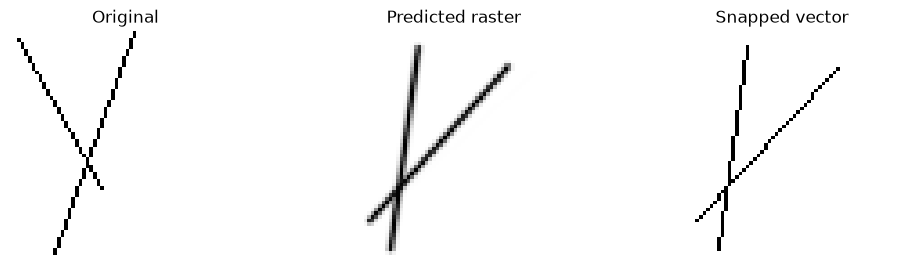

Example 1
True lines:
  (45, 22) to (8, 60), angle≈134°, confidence=1.00
  (60, 2) to (31, 52), angle≈120°, confidence=1.00
  (35, 44) to (60, 44), angle≈0°, confidence=1.00
Predicted snapped lines:
  (56, 12) to (7, 61), angle=135°, confidence=1.00
  (60, 3) to (15, 62), angle=128°, confidence=1.00
  (62, 3) to (23, 62), angle=123°, confidence=0.97


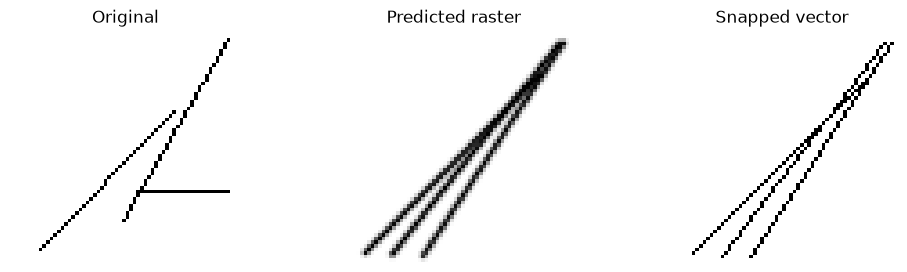

Example 2
True lines:
  (24, 8) to (25, 20), angle≈85°, confidence=1.00
  (17, 25) to (61, 25), angle≈0°, confidence=1.00
  (60, 3) to (37, 16), angle≈151°, confidence=1.00
Predicted snapped lines:
  (49, 11) to (9, 29), angle=155°, confidence=1.00
  (54, 9) to (10, 26), angle=159°, confidence=1.00


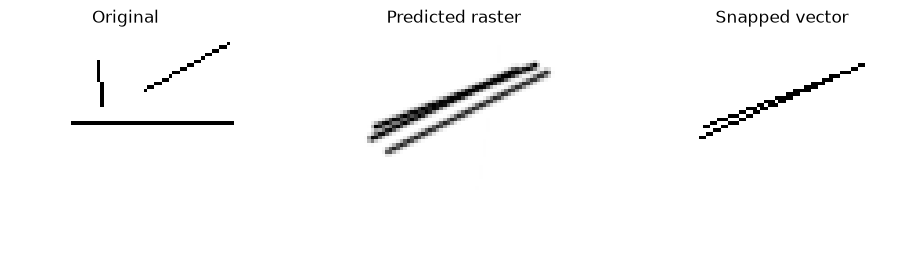

Example 3
True lines:
  (53, 32) to (53, 45), angle≈90°, confidence=1.00
Predicted snapped lines:
  (48, 25) to (53, 49), angle=78°, confidence=1.00


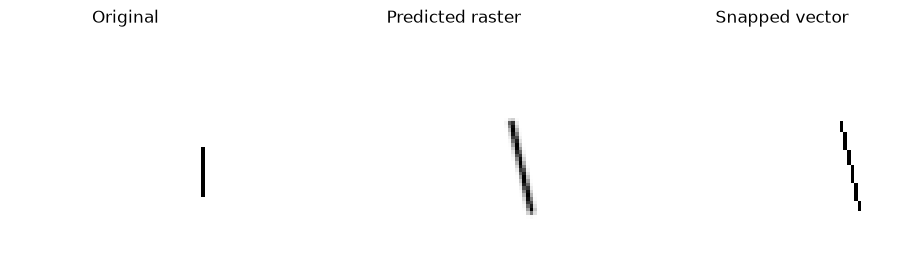

Example 4
True lines:
  (15, 8) to (15, 42), angle≈90°, confidence=1.00
  (59, 9) to (39, 28), angle≈136°, confidence=1.00
Predicted snapped lines:
  (31, 8) to (16, 53), angle=109°, confidence=1.00
  (53, 12) to (17, 46), angle=136°, confidence=1.00


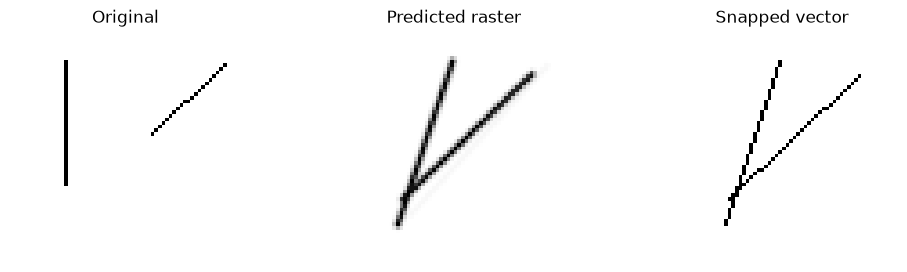

Example 5
True lines:
  (1, 4) to (1, 61), angle≈90°, confidence=1.00
  (10, 7) to (10, 59), angle≈90°, confidence=1.00
  (34, 30) to (21, 52), angle≈121°, confidence=1.00
  (21, 1) to (59, 39), angle≈45°, confidence=1.00
  (36, 29) to (54, 61), angle≈61°, confidence=1.00
Predicted snapped lines:
  (0, 0) to (1, 63), angle=89°, confidence=1.00
  (0, 34) to (47, 42), angle=9°, confidence=1.00
  (57, 44) to (0, 46), angle=178°, confidence=1.00
  (7, 2) to (50, 62), angle=55°, confidence=1.00
  (39, 1) to (45, 63), angle=84°, confidence=1.00


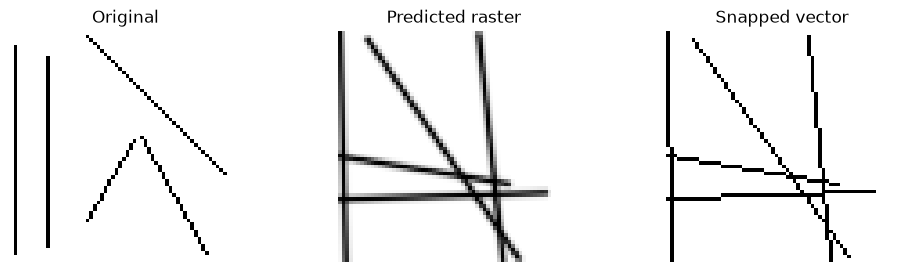

Example 6
True lines:
  (15, 18) to (7, 39), angle≈111°, confidence=1.00
  (11, 0) to (11, 59), angle≈90°, confidence=1.00
  (0, 20) to (61, 55), angle≈30°, confidence=1.00
  (15, 14) to (62, 26), angle≈14°, confidence=1.00
Predicted snapped lines:
  (15, 4) to (10, 58), angle=95°, confidence=1.00
  (3, 11) to (54, 49), angle=37°, confidence=1.00
  (5, 18) to (56, 53), angle=35°, confidence=1.00


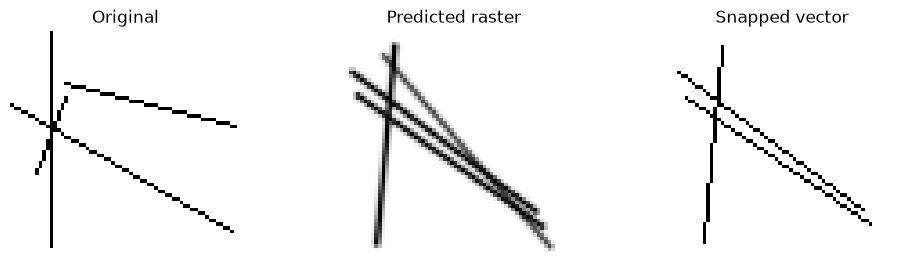

Example 7
True lines:
  (1, 2) to (60, 61), angle≈45°, confidence=1.00
  (9, 34) to (60, 34), angle≈0°, confidence=1.00
  (30, 11) to (41, 42), angle≈70°, confidence=1.00
  (62, 28) to (33, 45), angle≈150°, confidence=1.00
Predicted snapped lines:
  (1, 4) to (57, 58), angle=44°, confidence=1.00
  (1, 0) to (61, 63), angle=46°, confidence=1.00
  (3, 1) to (57, 63), angle=49°, confidence=1.00
  (6, 2) to (63, 63), angle=47°, confidence=1.00


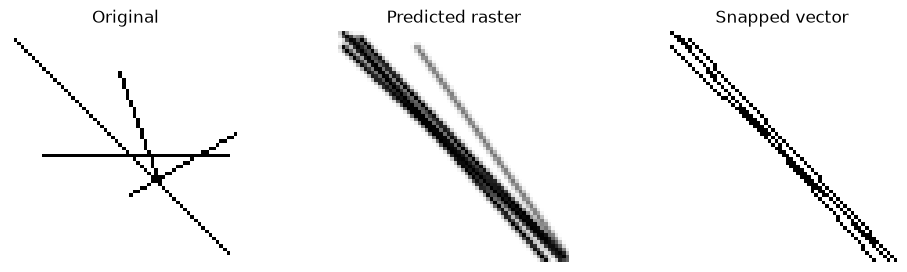

Example 8
True lines:
  (2, 18) to (2, 41), angle≈90°, confidence=1.00
  (19, 24) to (0, 57), angle≈120°, confidence=1.00
  (4, 14) to (24, 14), angle≈0°, confidence=1.00
  (28, 22) to (28, 45), angle≈90°, confidence=1.00
Predicted snapped lines:
  (0, 0) to (5, 63), angle=86°, confidence=1.00
  (1, 25) to (36, 34), angle=14°, confidence=1.00
  (43, 33) to (1, 40), angle=170°, confidence=1.00


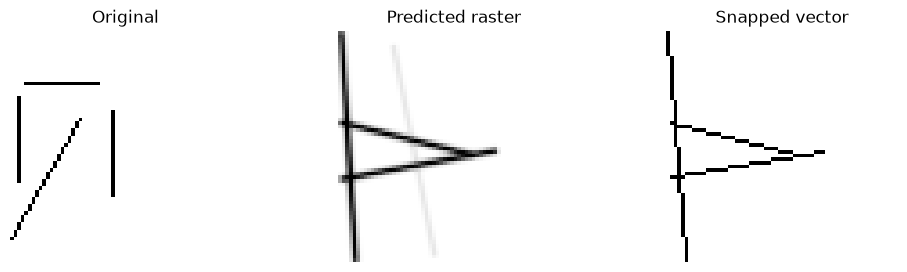

Example 9
True lines:
  (32, 0) to (32, 60), angle≈90°, confidence=1.00
  (53, 38) to (43, 54), angle≈122°, confidence=1.00
Predicted snapped lines:
  (34, 16) to (28, 53), angle=100°, confidence=1.00
  (48, 30) to (29, 42), angle=147°, confidence=1.00


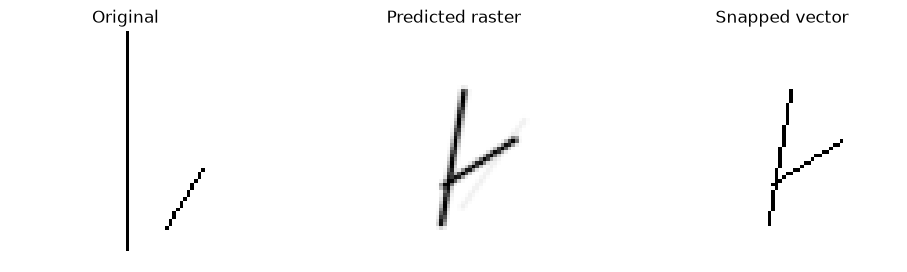

In [16]:
for sample_index in range(10):
    sample = X_test[sample_index:sample_index + 1]
    true_vector = y_test[sample_index]

    predicted_vector = vector_model.predict(sample, verbose=0)[0]
    predicted_outputs = training_model.predict(sample, verbose=0)
    predicted_raster = predicted_outputs[0][0]

    true_lines = decode_endpoint_vector(
        true_vector,
        img_size=IMG_SIZE,
        confidence_threshold=CONFIDENCE_THRESHOLD,
        snap=False
    )

    snapped_lines = decode_endpoint_vector(
        predicted_vector,
        img_size=IMG_SIZE,
        confidence_threshold=CONFIDENCE_THRESHOLD,
        snap=True
    )

    snapped_raster = rasterise_decoded_lines(snapped_lines, img_size=IMG_SIZE)

    print("Example", sample_index)

    print("True lines:")
    for line in true_lines:
        print(
            f"  ({line['x1']}, {line['y1']}) to ({line['x2']}, {line['y2']}), "
            f"angle≈{line['angle']}°, confidence={line['confidence']:.2f}"
        )

    print("Predicted snapped lines:")
    for line in snapped_lines:
        print(
            f"  ({line['x1']}, {line['y1']}) to ({line['x2']}, {line['y2']}), "
            f"angle={line['angle']}°, confidence={line['confidence']:.2f}"
        )

    plt.figure(figsize=(12, 3))

    plt.subplot(1, 3, 1)
    plt.imshow(sample.squeeze(), cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(predicted_raster.squeeze(), cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    plt.title("Predicted raster")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(snapped_raster.squeeze(), cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    plt.title("Snapped vector")
    plt.axis("off")

    plt.show()
